In [8]:
# Part 3: Simple Model as Baseline
# Implements Binary label grouping reliable and fake.
# Implements Text only baseline model TF-IDF and MultinomialNB.
# Implements Validation and test metrics like accuracy, precision, recall, F1 and confusion matrices.

from pathlib import Path
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [9]:
# Paths loading
if Path("data").exists():
    PROJECT_ROOT = Path(".")
elif Path("..").joinpath("data").exists():
    PROJECT_ROOT = Path("..")


PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_path = PROCESSED_DIR / "train.csv"
val_path = PROCESSED_DIR / "val.csv"
test_path = PROCESSED_DIR / "test.csv"

In [ ]:
# Load splits files
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

required_cols = ["content", "type"]
for c in required_cols:
    if c not in train_df.columns:
        raise ValueError(f"Missing required column: {c}")

Train: 166,434
Val  : 20,804
Test : 20,805


In [10]:
# Controlling the rows to load and performing training and validation
MAX_TRAIN_ROWS = 120_000
MAX_VAL_ROWS = 30_000
MAX_TEST_ROWS = 30_000

if MAX_TRAIN_ROWS is not None and len(train_df) > MAX_TRAIN_ROWS:
    train_df = train_df.sample(MAX_TRAIN_ROWS, random_state=42)
if MAX_VAL_ROWS is not None and len(val_df) > MAX_VAL_ROWS:
    val_df = val_df.sample(MAX_VAL_ROWS, random_state=42)
if MAX_TEST_ROWS is not None and len(test_df) > MAX_TEST_ROWS:
    test_df = test_df.sample(MAX_TEST_ROWS, random_state=42)

print("Rows used for this run:")
print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

Rows used for this run:
Train: 117,072
Val  : 20,301
Test : 20,302


In [21]:
# Label mapping
# Real is set to 0, Fake is set to 1
real_labels = ["reliable", "political", "unbiased"]
fake_labels = ["fake", "bias", "rumor", "hate", "unreliable", "clickbait", "conspiracy", "satire", "junksci"]

def map_binary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["type"] = out["type"].astype(str).str.lower().str.strip()
    keep = set(real_labels + fake_labels)
    out = out[out["type"].isin(keep)].copy()
    out["label"] = out["type"].apply(lambda x: 1 if x in fake_labels else 0).astype(int)
    out["content"] = out["content"].fillna("").astype(str)
    out = out[out["content"].str.len() > 0]
    return out


train_df = map_binary(train_df)
val_df = map_binary(val_df)
test_df = map_binary(test_df)

print("Rows after filtering/mapping:")
print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

print("\nTrain label balance (0=Real, 1=Fake):")
print(train_df["label"].value_counts(normalize=True))

Rows after filtering/mapping:
Train: 117,072
Val  : 20,301
Test : 20,302

Train label balance (0=Real, 1=Fake):
label
1    0.649617
0    0.350383
Name: proportion, dtype: float64


## Label-grouping limitation (for report)

This binary grouping is practical for baseline training, but it has limitations:
- Some classes (e.g., `satire`, `political`, `bias`) are not always strictly fake.
- Label noise can reduce model quality and interpretability.
- Results should be interpreted as **fake-like vs reliable**, not perfect truth detection.

In [ ]:
# NLTK resources setup and preprocessing to clear text like lower case, remove digits, remove punctuation, remove stop words, lemmatize
# Then added some functions to show results and confusion matrix
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stop_words]
    words = [lemmatizer.lemmatize(w, pos="v") for w in words]
    return " ".join(words)


def evaluate_model(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def show_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

In [ ]:
# Articles are preprocessed and turned into TF-IDF vectors (100,000 features). Train has 117,072 rows, val 20,301, and test 20,302, all with the same feature set learned from the training data
X_train_clean = train_df["content"].apply(preprocess_text)
X_val_clean = val_df["content"].apply(preprocess_text)
X_test_clean = test_df["content"].apply(preprocess_text)

# Simple tuning
# - use unigrams+bigrams
# - slightly higher feature cap
# - sublinear tf scaling
vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=100_000,
    sublinear_tf=True,
)

X_train_text = vectorizer.fit_transform(X_train_clean)
X_val_text = vectorizer.transform(X_val_clean)
X_test_text = vectorizer.transform(X_test_clean)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Text feature matrix shapes:")
print("Train:", X_train_text.shape)
print("Val  :", X_val_text.shape)
print("Test :", X_test_text.shape)

Preprocessing text...
Text feature matrix shapes:
Train: (117072, 100000)
Val  : (20301, 100000)
Test : (20302, 100000)


In [24]:
# Single baseline TF-IDF + MultinomialNB
# Small hyperparameter based search for alpha on validation set
alpha_grid = [0.1, 0.3, 0.5, 1.0]
val_rows = []

best_alpha = None
best_acc = -1
best_model = None
best_val_pred = None

for alpha in alpha_grid:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_text, y_train)
    pred = model.predict(X_val_text)
    m = evaluate_model(f"NB (alpha={alpha}) - val", y_val, pred)
    m["alpha"] = alpha
    val_rows.append(m)

    if m["accuracy"] > best_acc:
        best_acc = m["accuracy"]
        best_alpha = alpha
        best_model = model
        best_val_pred = pred

nb_model = best_model
val_pred_nb = best_val_pred

val_results = pd.DataFrame(val_rows).sort_values("accuracy", ascending=False)
print(f"Best alpha on validation: {best_alpha}")

print(f"Accuracy: {best_acc:.4f}")
print(classification_report(y_val, val_pred_nb, target_names=["Real", "Fake"], zero_division=0))

val_results

Best alpha on validation: 0.1
Accuracy: 0.8335
              precision    recall  f1-score   support

        Real       0.74      0.80      0.77      7087
        Fake       0.89      0.85      0.87     13214

    accuracy                           0.83     20301
   macro avg       0.82      0.83      0.82     20301
weighted avg       0.84      0.83      0.83     20301



,model,accuracy,precision,recall,f1,alpha
0,NB (alpha=0.1) - val,0.833456,0.889179,0.850083,0.869192,0.1
1,NB (alpha=0.3) - val,0.830501,0.887111,0.847435,0.866819,0.3
2,NB (alpha=0.5) - val,0.830255,0.885660,0.848797,0.866837,0.5
3,NB (alpha=1.0) - val,0.829959,0.879667,0.855835,0.867587,1.0


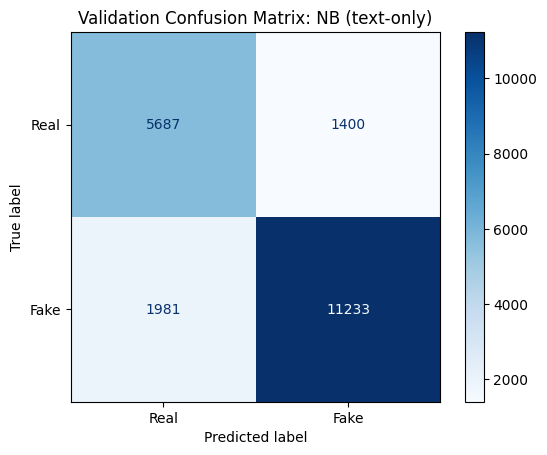

In [25]:
show_confusion(y_val, val_pred_nb, "Validation Confusion Matrix: NB (text-only)")

In [27]:
# test evaluation for the same baseline model
print(f"Final model: NB (best alpha={best_alpha})")

test_pred = nb_model.predict(X_test_text)
test_metrics = evaluate_model(f"NB (alpha={best_alpha}) - test", y_test, test_pred)

print("Test Metrics:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(classification_report(y_test, test_pred, target_names=["Real", "Fake"], zero_division=0))

pd.DataFrame([test_metrics])

Final model: NB (best alpha=0.1)
Test Metrics:
Accuracy: 0.8341
              precision    recall  f1-score   support

        Real       0.74      0.80      0.77      7087
        Fake       0.89      0.85      0.87     13215

    accuracy                           0.83     20302
   macro avg       0.82      0.83      0.82     20302
weighted avg       0.84      0.83      0.84     20302



,model,accuracy,precision,recall,f1
0,NB (alpha=0.1) - test,0.834056,0.890219,0.849868,0.869575


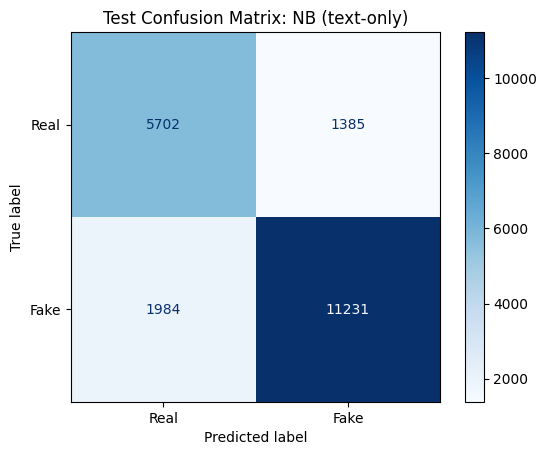

In [28]:
show_confusion(y_test, test_pred, "Test Confusion Matrix: NB (text-only)")